# Acne Classification Using CNN
## Goal:
Build a deep learning model to classify acne types using a CNN model, while addressing dataset imbalance through oversampling and augmentation.

## ----------------------------
## 1. IMPORTS
## ----------------------------

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

I0000 00:00:1777278527.709154   24518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777278527.715067   24518 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777278528.120678   24518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777278529.831283   24518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 📦 2. Download Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tiswan14/acne-dataset-image")

print("Path to dataset files:", path)

/home/pratama/dev-python/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/pratama/.cache/kagglehub/datasets/tiswan14/acne-dataset-image/versions/1


## 📂 3. Dataset Paths & Parameters

In [3]:
base_dir = r"/home/pratama/.cache/kagglehub/datasets/tiswan14/acne-dataset-image/versions/1/AcneDataset"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

## 🧠 4. Load Datasets

In [4]:

# ----------------------------
# PARAMETERS
# ----------------------------
# Jumlah berapa kali belajar (32 kali)
BATCH_SIZE = 50
# Original image size
# Resize semua gambar
IMAGE_SIZE = 128
# Adjustment image size
# IMAGE_SIZE = 60

# ----------------------------
# LOAD DATASETS
# ----------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, label_mode='int', image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, shuffle=True
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, label_mode='int', image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, label_mode='int', image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)
import json
# export classname
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

Found 4240 files belonging to 8 classes.
Found 1323 files belonging to 8 classes.
Found 1320 files belonging to 8 classes.
Classes: ['Barier', 'Blackheads', 'Bopeng', 'Cyst', 'Papules', 'Pustules', 'Whiteheads', 'darkspots']


E0000 00:00:1777278532.496063   24518 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 🖼️ 5. Visualize Sample Images



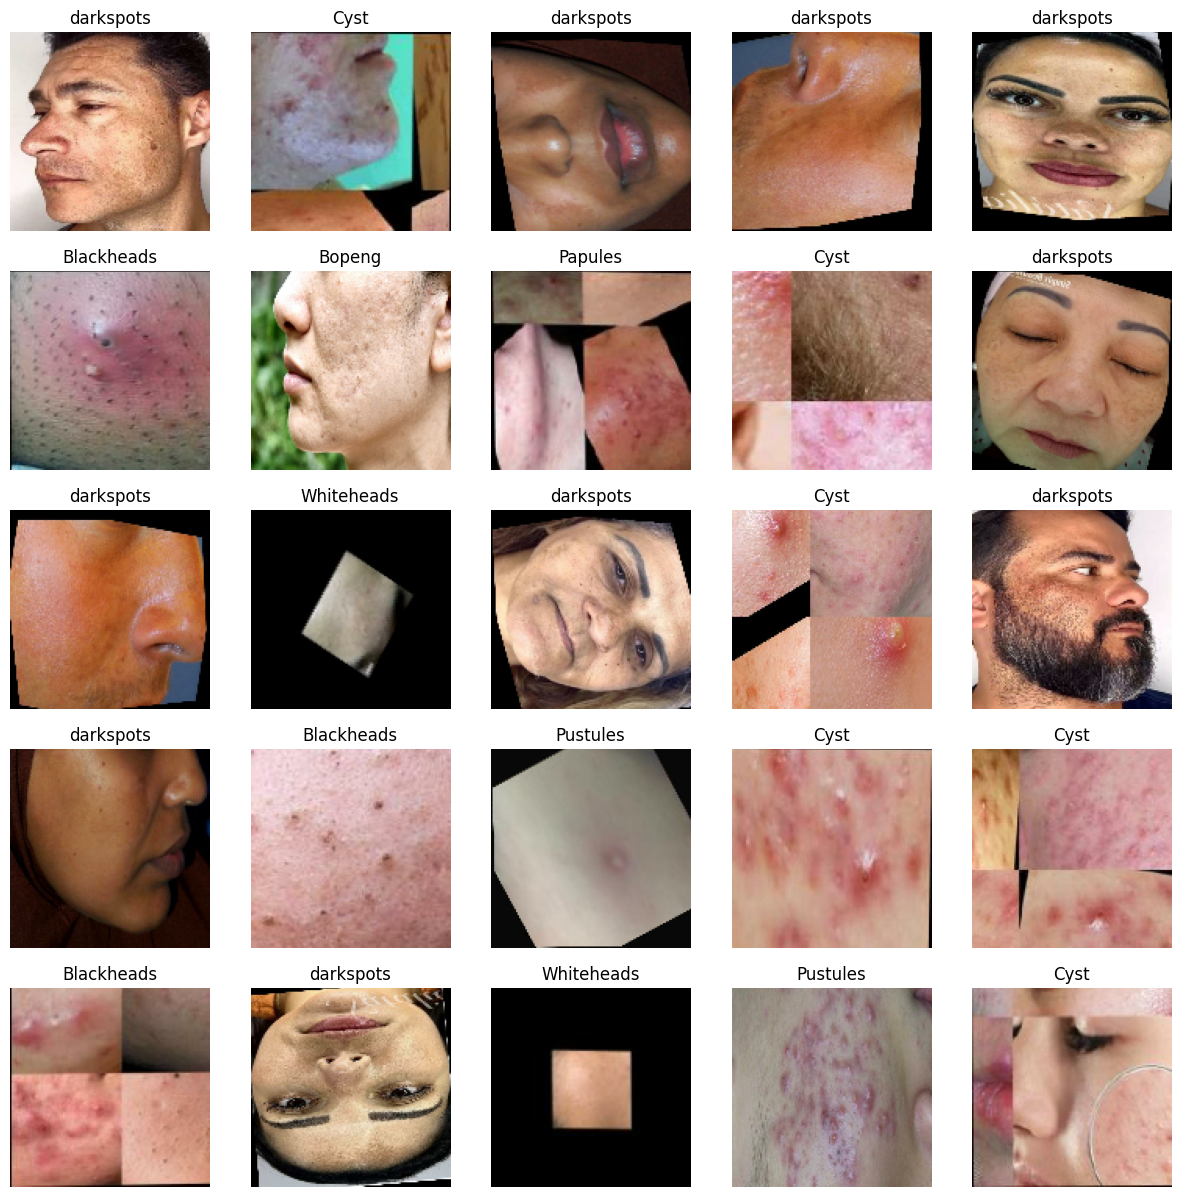

In [5]:
for image, label in train_ds.take(1):
    plt.figure(figsize=(15, 15))
    for i in range(25):  # dari 9 jadi 25
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(image[i].numpy().astype("uint8"))

        label_index = label[i].numpy()
        plt.title(class_names[label_index])
        plt.axis("off")

## 📊 6. Class Distribution

In [6]:
for folder in ['train', 'valid', 'test']:
    folder_path = os.path.join(base_dir, folder)
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):  # Only count directories
            print(f"{folder}/{cls}:", len(os.listdir(cls_path)))

train/Cyst: 645
train/Pustules: 584
train/Blackheads: 735
train/Whiteheads: 193
train/darkspots: 1362
train/Bopeng: 70
train/Papules: 621
train/Barier: 30
valid/Cyst: 206
valid/Pustules: 217
valid/Blackheads: 240
valid/Whiteheads: 49
valid/darkspots: 382
valid/Bopeng: 10
valid/Papules: 209
valid/Barier: 10
test/Cyst: 189
test/Pustules: 205
test/Blackheads: 265
test/Whiteheads: 57
test/darkspots: 382
test/Bopeng: 10
test/Papules: 202
test/Barier: 10


### 📌 Observation:
Whiteheads (193 images) are underrepresented, which can bias the model.
We'll fix this using oversampling and augmentation.

## ⚖️ 7. Compute Class Weights

In [7]:
counts = [30, 40, 735, 70, 645, 621, 584, 193]
classes = np.arange(8)
y = np.repeat(classes, counts)
class_weight_dict = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=y)))
print("Class weights:", class_weight_dict)



Class weights: {np.int64(0): np.float64(12.158333333333333), np.int64(1): np.float64(9.11875), np.int64(2): np.float64(0.4962585034013605), np.int64(3): np.float64(5.210714285714285), np.int64(4): np.float64(0.5655038759689922), np.int64(5): np.float64(0.5873590982286635), np.int64(6): np.float64(0.6245719178082192), np.int64(7): np.float64(1.8898963730569949)}


## 🔧 8. Preprocessing & Normalization

In [8]:
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = valid_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


## 🔁 9. Data Augmentation

In [9]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.15),
    RandomZoom(0.15)
])


## 🔄 10. Oversampling Minority Class (Whiteheads)

In [10]:
# Unbatch the dataset
train_ds_unbatched = train_ds.unbatch()

# Split dataset by class
class_datasets = []
for i in range(len(class_names)):
    class_datasets.append(train_ds_unbatched.filter(lambda x, y: y==i))

# Oversample all minority classes to match target_count
target_count = max(counts)
for i in range(len(class_names)):
    if counts[i] < target_count:
        repeat_times = target_count // counts[i]
        remainder = target_count % counts[i]
        oversampled_class = class_datasets[i].repeat(repeat_times)
        oversampled_class = oversampled_class.concatenate(class_datasets[i].take(remainder))
        class_datasets[i] = oversampled_class
# Combine all classes
balanced_ds = class_datasets[0]
for ds in class_datasets[1:]:
    balanced_ds = balanced_ds.concatenate(ds)

# Shuffle, augment, and batch correctly
balanced_ds = balanced_ds.shuffle(5000)
balanced_ds = balanced_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
balanced_ds = balanced_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### ✅ Result: 
The dataset is now balanced across all acne types.

In [11]:
valid_ds = valid_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(tf.data.AUTOTUNE)

## 🧰 11. Build CNN Model

In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,232 (2.55 MB)

 Trainable params: 668,232 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 🏋️‍♂️ 12. Train Model


In [ ]:
# ----------------------------
# CALLBACKS
# ----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# ----------------------------
# TRAIN MODEL
# ----------------------------
history = model.fit(
    balanced_ds,
    validation_data=valid_ds,
    epochs=100,
    # epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=2
)
# model.save("model/acne_model.keras")
model.save("acne_model.keras")



Epoch 1/100


I0000 00:00:1777278546.014624   25451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 120 of 5000
I0000 00:00:1777278565.875599   25451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 283 of 5000
I0000 00:00:1777278575.978467   25451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 361 of 5000
I0000 00:00:1777278595.923299   25451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 530 of 5000
I0000 00:00:1777278616.020236   25451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 698 of 5000
I0000 00:00:1777278635.857966   25451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 3919 of 5000
I0000 00:00:1777278640.257751   25451 shuffle_dataset_op.cc:483] Shuffle buffer filled.
W0000 00:00:17772

531/531 - 407s - 767ms/step - accuracy: 0.6998 - loss: 3.7787 - val_accuracy: 0.4429 - val_loss: 2.5493 - learning_rate: 0.0010
Epoch 2/100


I0000 00:00:1777278951.671702   26652 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 110 of 5000
I0000 00:00:1777278961.732388   26652 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 209 of 5000
I0000 00:00:1777278981.688261   26652 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 420 of 5000
I0000 00:00:1777279001.724730   26652 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 631 of 5000
I0000 00:00:1777279021.606954   26652 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 3359 of 5000
I0000 00:00:1777279028.383229   26652 shuffle_dataset_op.cc:483] Shuffle buffer filled.
W0000 00:00:1777279095.767635   26654 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 983060

531/531 - 379s - 713ms/step - accuracy: 0.6281 - loss: 3.9811 - val_accuracy: 0.3462 - val_loss: 2.5348 - learning_rate: 0.0010
Epoch 3/100


...

W0000 00:00:1777282059.697974   28280 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1777282061.041380   28278 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 108 of 5000
W0000 00:00:1777282062.878151   28279 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777282065.897150   28280 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram bu

531/531 - 388s - 730ms/step - accuracy: 0.7306 - loss: 3.3821 - val_accuracy: 0.4369 - val_loss: 2.2502 - learning_rate: 0.0010
Epoch 11/100


W0000 00:00:1777282446.974626   28515 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1777282448.516844   28513 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 111 of 5000
W0000 00:00:1777282450.043276   28514 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777282453.007160   28516 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram bu

531/531 - 386s - 727ms/step - accuracy: 0.7228 - loss: 3.3549 - val_accuracy: 0.4512 - val_loss: 2.3853 - learning_rate: 0.0010
Epoch 12/100


W0000 00:00:1777282833.983219   28751 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1777282834.663707   28749 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 101 of 5000
W0000 00:00:1777282837.156109   28750 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777282840.272463   28751 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram bu

## 📈 13. Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.6743 - loss: 0.9208
Test Accuracy: 0.6742919683456421


## 🔍 14. Confusion Matrix & Classification Report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true and predicted labels for test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


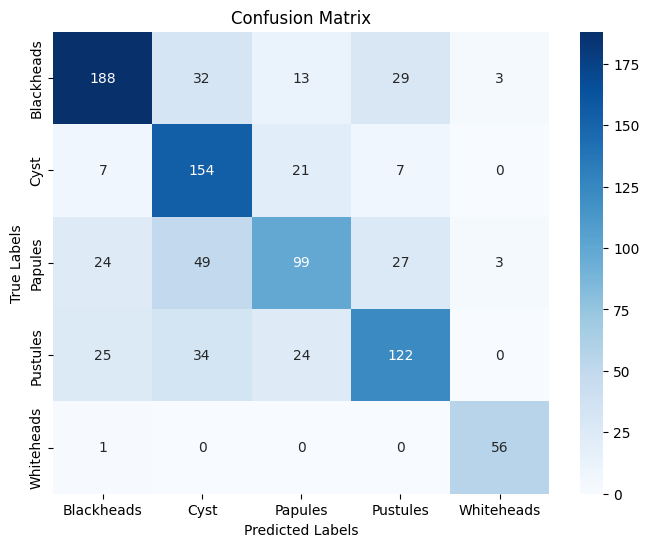

In [ ]:
# ----------------------------
# CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()



In [ ]:
# ----------------------------
# CLASSIFICATION REPORT
# ----------------------------
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:\n", report)



Classification Report:
               precision    recall  f1-score   support

  Blackheads       0.77      0.71      0.74       265
        Cyst       0.57      0.81      0.67       189
     Papules       0.63      0.49      0.55       202
    Pustules       0.66      0.60      0.63       205
  Whiteheads       0.90      0.98      0.94        57

    accuracy                           0.67       918
   macro avg       0.71      0.72      0.71       918
weighted avg       0.68      0.67      0.67       918



## 📊 15. Accuracy and Loss Curves


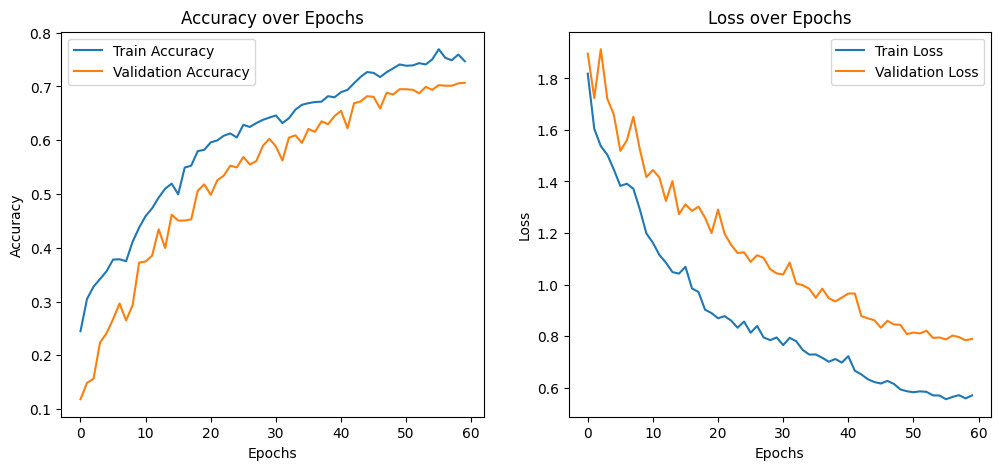

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()